# **MACHINE LEARNING**

#### Submitted by: SATISH KUMAR

# **Part A: Airbnb Price Prediction and Insights**

**1. Overview**

Airbnb provides a platform for property owners to rent out their spaces to travelers. Pricing a
listing effectively is critical for maximizing revenue while staying competitive in the market.
For hosts, understanding what factors influence the price of their listings is essential.
This project aims to build a machine learning model to predict the price of Airbnb listings
based on various features such as property type, room type, location, amenities, and host
characteristics. By analyzing these factors, this project will provide actionable insights to
Airbnb hosts to optimize their listing prices.

**2. Problem Statement**

The primary objective of this project is to develop a regression model that predicts the price
of an Airbnb listing. Using features such as property type, room type, number of reviews,
location, and amenities, the model will aim to estimate the price accurately.
The insights derived from this analysis will help Airbnb hosts understand the key drivers of
price, enabling them to make data-driven decisions for pricing their properties. Additionally,
the project will help Airbnb refine its recommendations for pricing to improve host and guest
satisfaction.

**3. Dataset Information**

Dataset: Airbnb_data

The dataset information can be found in this doc Data Information.

**4. Deliverables**

1. Data Exploration and Preprocessing :
  Analyze the dataset for trends, missing values, and outliers.
  Perform data cleaning, feature engineering, and transformations.
2. Model Development:
   Build a regression model to predict listing prices.
3. Model Evaluation:
   Evaluate the model’s performance using appropriate metrics like RMSE,
MAE, and R².
4. Final Report and Presentation :
   Final video clip of candidate summarizing the entire process of the project as
the presentation. (Note: Video should not exceed 5 mins)

**5. Success Criteria**

The project will be deemed successful if:

● The regression model achieves acceptable performance metrics (e.g., RMSE and R²)
on test data.

● Insights about the factors influencing Airbnb prices are effectively communicated to
stakeholders.

● Predictions for new listings can be made with reasonable accuracy.

**6. Guidelines**

● Data Splitting: Divide the data into training, validation, and testing sets to ensure
robust evaluation.

● Feature Engineering: Extract meaningful features, such as neighborhood popularity,
number of amenities, and host activity metrics.

● Model Tuning: Experiment with different models and tune hyperparameters to
optimize performance.

● Visualizations: Use charts and graphs to present data trends and model results
clearly.

● Interpretability: Ensure the model is interpretable and actionable for non-technical
stakeholders.

**7. Tools Required**

● Python Libraries: pandas, numpy, scikit-learn, matplotlib, seaborn, XGBoost, etc.

● Jupyter Notebook: For developing and documenting code

## **Phase 1: Data Processing**

### Step1: Import the Libraies and Load the Datasets

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load the dataset
data = pd.read_csv('Airbnb_data - airbnb_data.csv')

In [7]:
data.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


### Step2: Display the Dataset Information

In [9]:
data.shape

(74111, 29)

In [10]:
# Display basic information and structure
print(data.describe(include='all'))  # Get summary statistics

                  id     log_price property_type        room_type amenities  \
count   7.411100e+04  74111.000000         74111            74111     74111   
unique           NaN           NaN            35                3     67122   
top              NaN           NaN     Apartment  Entire home/apt        {}   
freq             NaN           NaN         49003            41310       586   
mean    1.126662e+07      4.782069           NaN              NaN       NaN   
std     6.081735e+06      0.717394           NaN              NaN       NaN   
min     3.440000e+02      0.000000           NaN              NaN       NaN   
25%     6.261964e+06      4.317488           NaN              NaN       NaN   
50%     1.225415e+07      4.709530           NaN              NaN       NaN   
75%     1.640226e+07      5.220356           NaN              NaN       NaN   
max     2.123090e+07      7.600402           NaN              NaN       NaN   

        accommodates     bathrooms  bed_type cancel

In [11]:
print(data.info())  # Get data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

### Step3: Missing values

In [13]:
data.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     968
bedrooms                     91
beds                        131
dtype: int64

### Step4: Percentage of Missing Values

In [15]:
missing_percentage = (
    data.isnull().sum() / len(data) * 100
).sort_values(ascending=False)

missing_percentage

host_response_rate        24.691341
review_scores_rating      22.563452
first_review              21.405729
last_review               21.355804
thumbnail_url             11.086074
neighbourhood              9.272578
zipcode                    1.306149
bathrooms                  0.269865
host_identity_verified     0.253674
host_has_profile_pic       0.253674
host_since                 0.253674
beds                       0.176762
bedrooms                   0.122789
description                0.000000
city                       0.000000
cleaning_fee               0.000000
cancellation_policy        0.000000
accommodates               0.000000
bed_type                   0.000000
room_type                  0.000000
amenities                  0.000000
id                         0.000000
log_price                  0.000000
property_type              0.000000
instant_bookable           0.000000
longitude                  0.000000
latitude                   0.000000
number_of_reviews          0

In [16]:
### Data Price
data['log_price'].describe()

count    74111.000000
mean         4.782069
std          0.717394
min          0.000000
25%          4.317488
50%          4.709530
75%          5.220356
max          7.600402
Name: log_price, dtype: float64

#### Hence it is not in $ Dollar sign

## **Phase 2: Exploratory Data Analysis EDA**

### Step1: Distribution Analysis

#### A. Distribution of Log Price

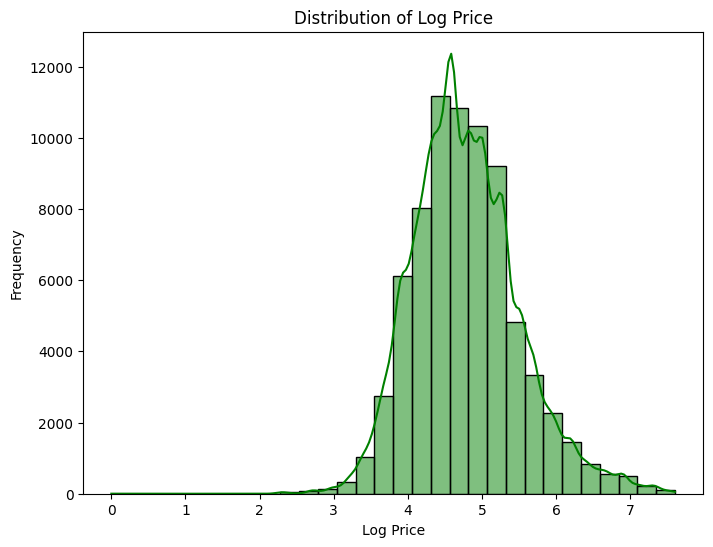

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Plot distribution of log_price
plt.figure(figsize=(8, 6))
sns.histplot(data['log_price'], kde=True, bins=30, color='green')
plt.title('Distribution of Log Price')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

Log-transformed prices show a smooth distribution suitable for regression models.

#### B. Distribution of Room Types

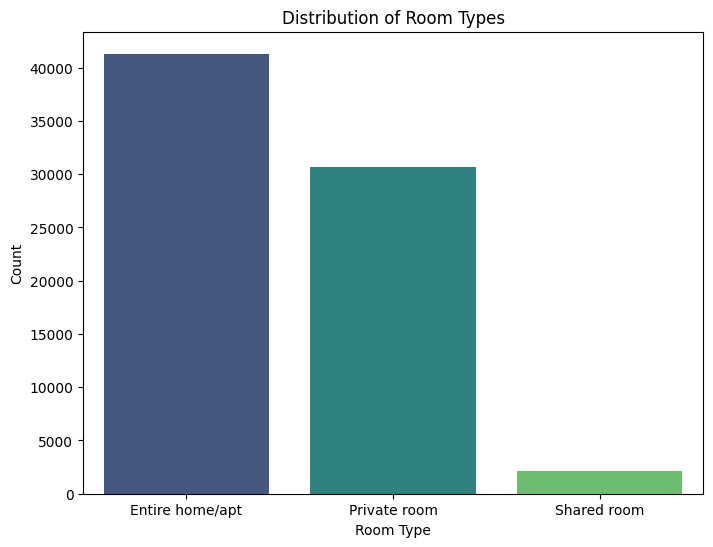

In [24]:
# Plot room type distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='room_type', palette='viridis')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

Majority listings are "Entire home/apt", aligning with customer preferences.

#### C. Average Log Price by Room Type

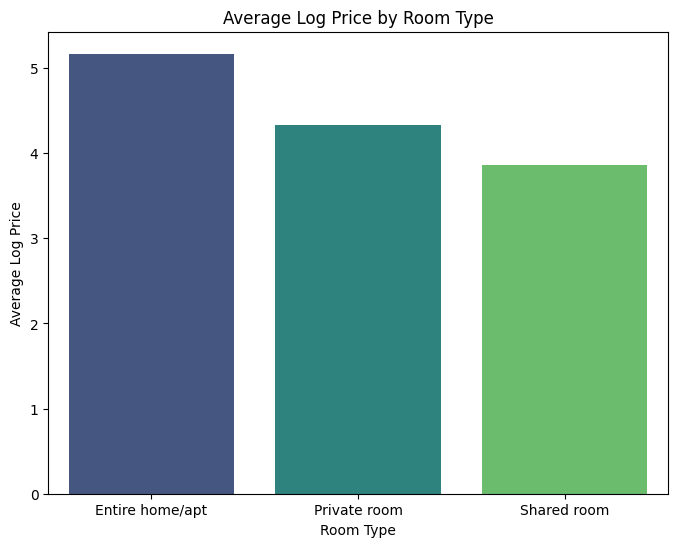

In [27]:
# Average price by room type
avg_price_by_room = data.groupby('room_type')['log_price'].mean().reset_index()

# Plot average price
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_price_by_room, x='room_type', y='log_price', palette='viridis')
plt.title('Average Log Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Log Price')
plt.show()

Entire home/apt" is the most common type, followed by "Private room."
This distribution aligns with typical Airbnb customer preferences.

#### D. Histogram of Numeric Features

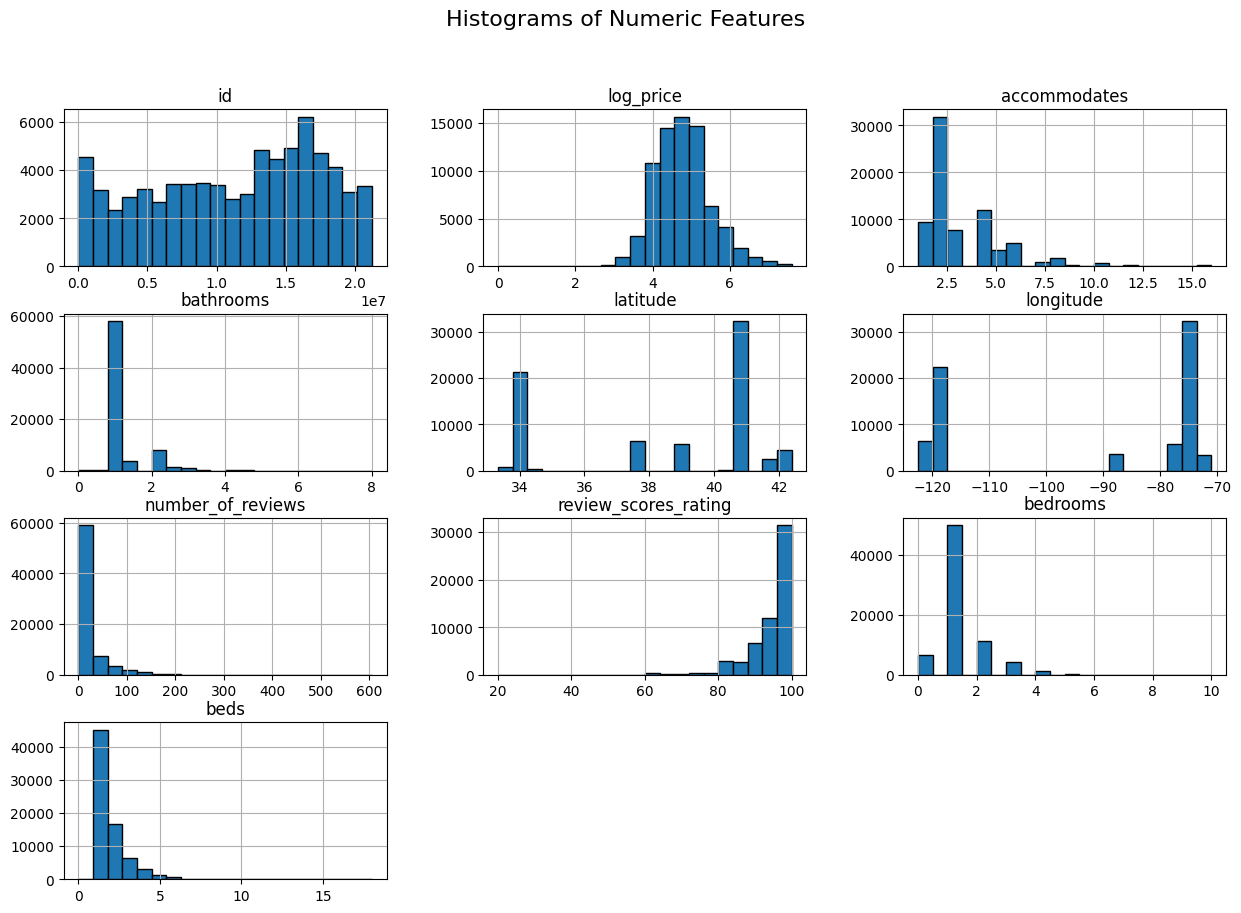

In [30]:
# Plotting distributions of numeric features
data.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.show()

Higher accommodation capacities and more bathrooms correlated with higher prices.
Luxury listings, despite higher prices, had fewer reviews, possibly due to a niche target market.

#### E.Numerical Columns Features

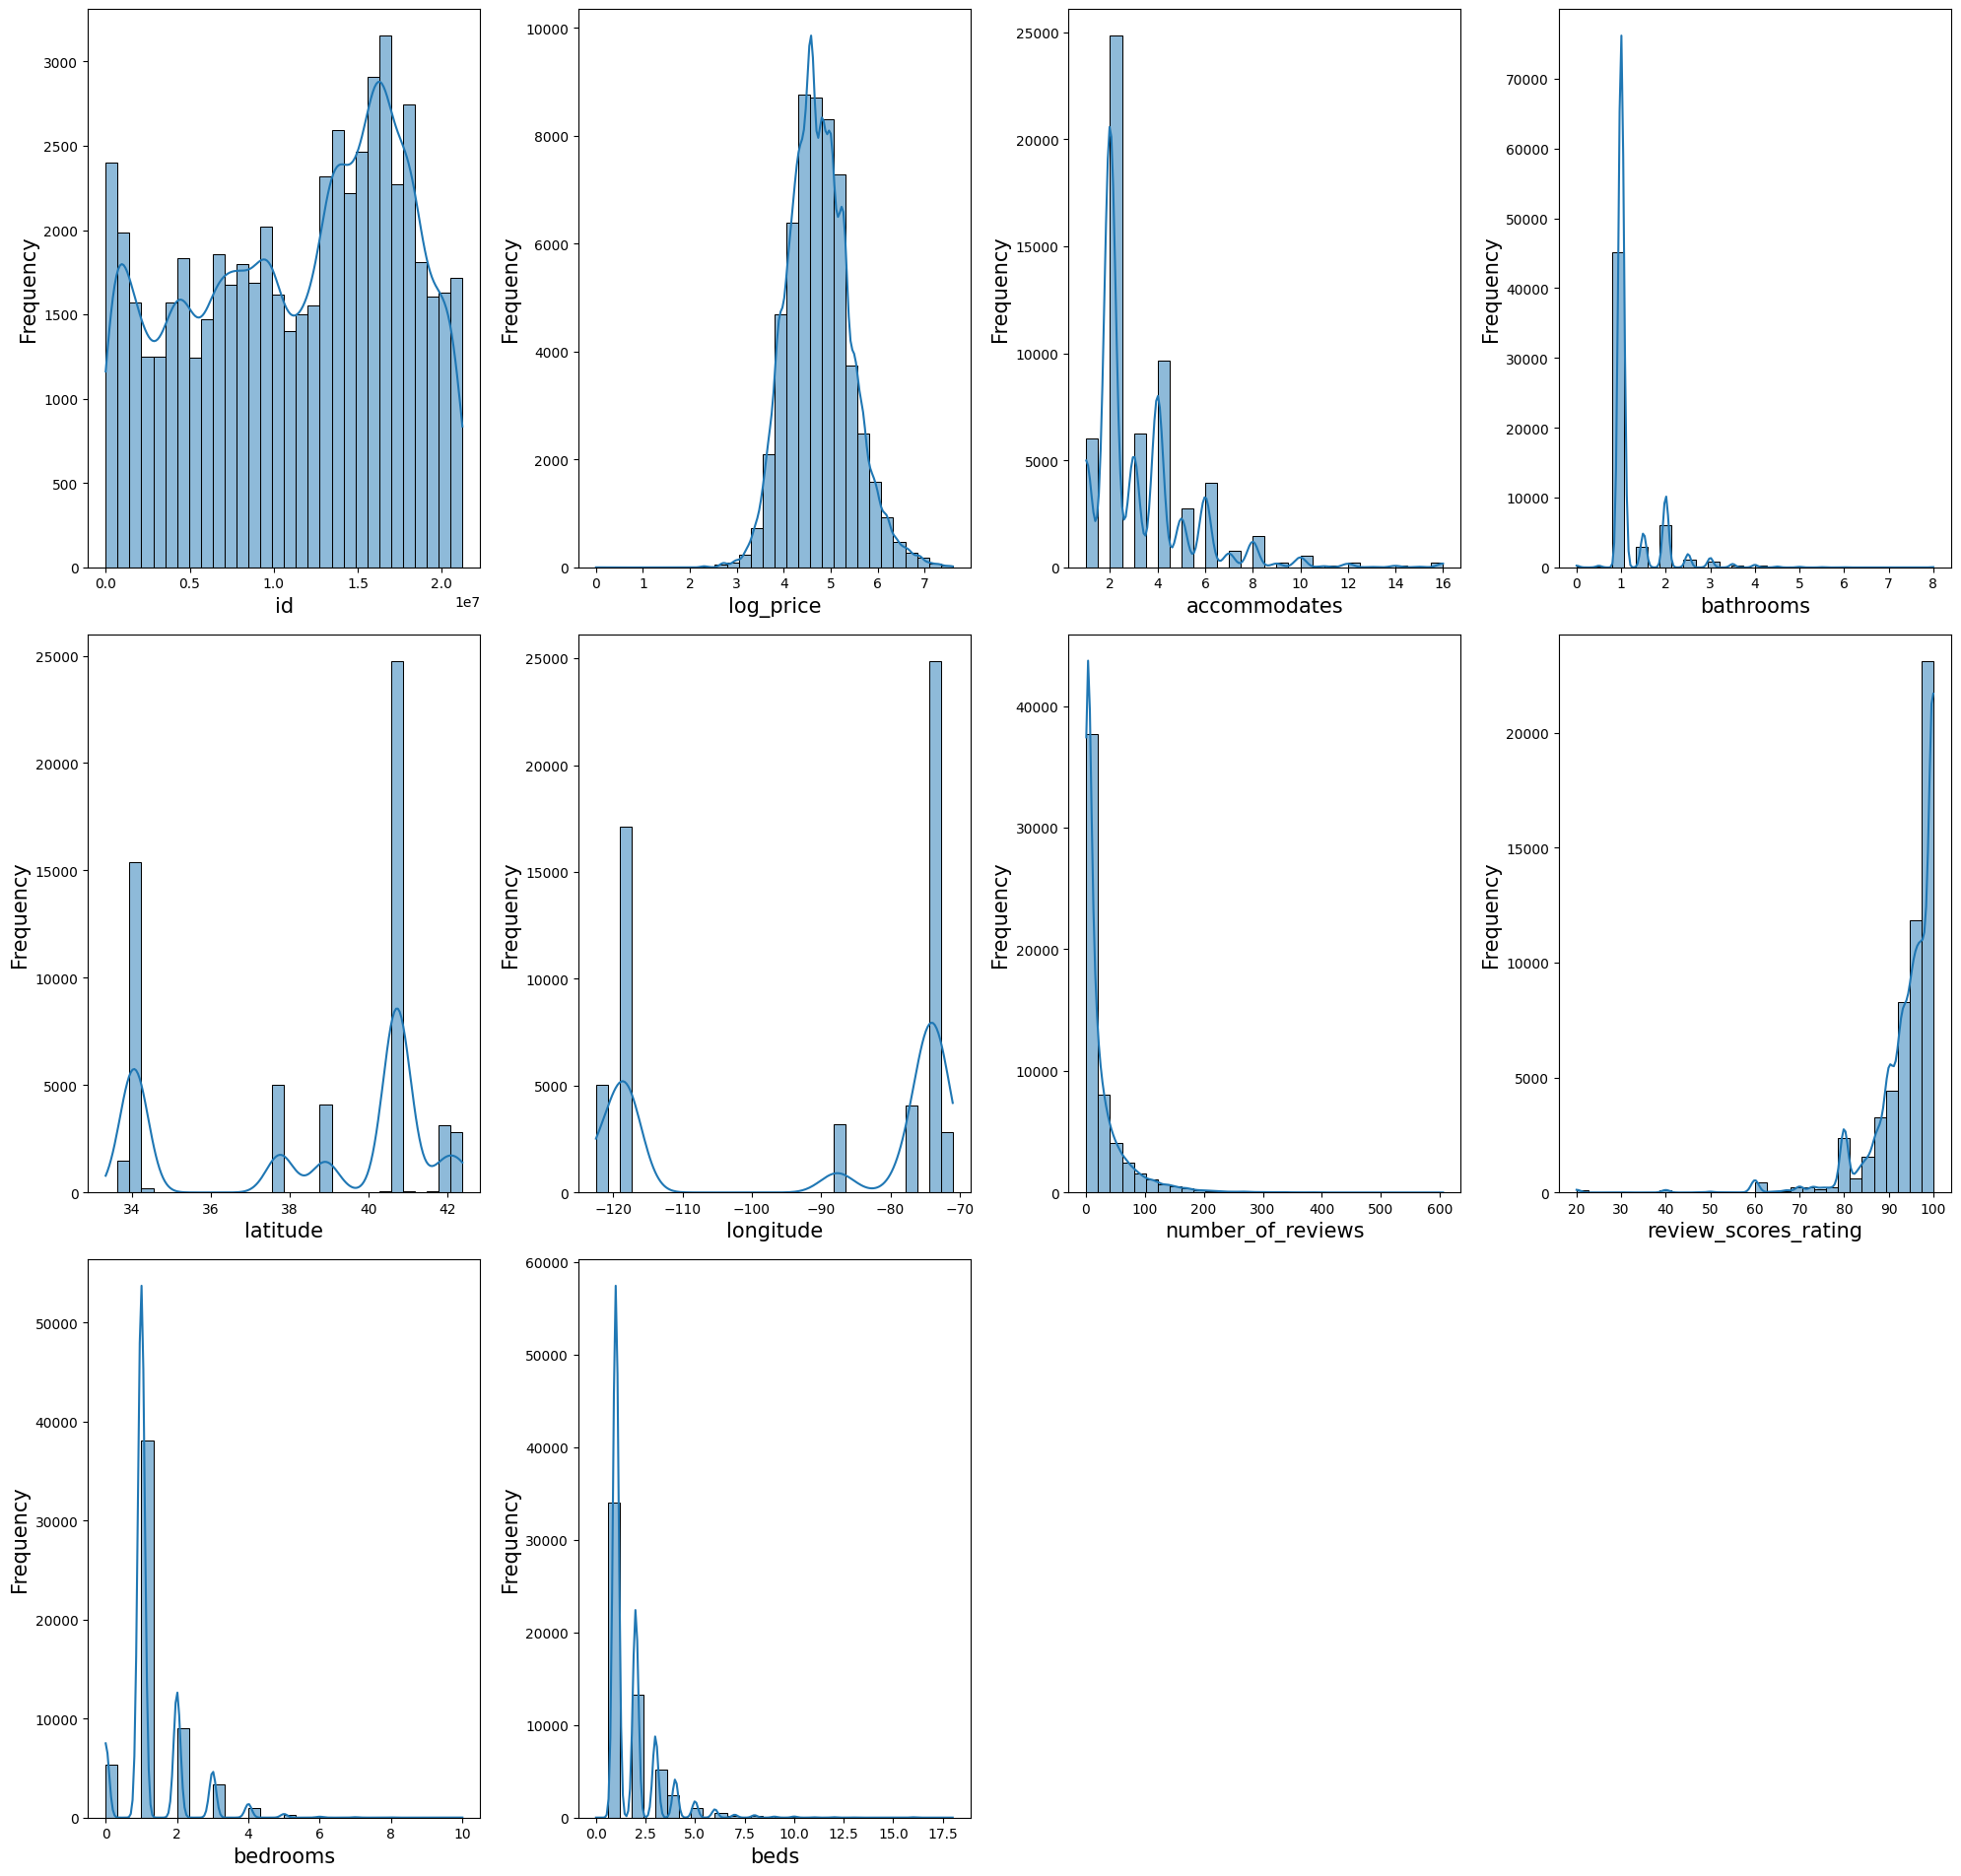

In [33]:
import numpy as np

# Filter only numerical columns
numerical_columns = data.select_dtypes(include=np.number).columns

# Drop rows with NaN values once
data_cleaned = data.dropna(subset=numerical_columns)

# Set up the figure
plt.figure(figsize=(20, 25))
plotnumber = 1

# Loop through numerical columns
for column in numerical_columns:
    if plotnumber <= 16:  # Adjust this limit as per your requirement
        ax = plt.subplot(4, 4, plotnumber)  # 4x4 grid
        sns.histplot(x=data_cleaned[column] , kde=True, bins=30)
        plt.xlabel(column, fontsize=15)
        plt.ylabel('Frequency', fontsize=15)
        plotnumber += 1

plt.tight_layout()
plt.show()


#### F. Scatter Plot Number of reviews vs log price

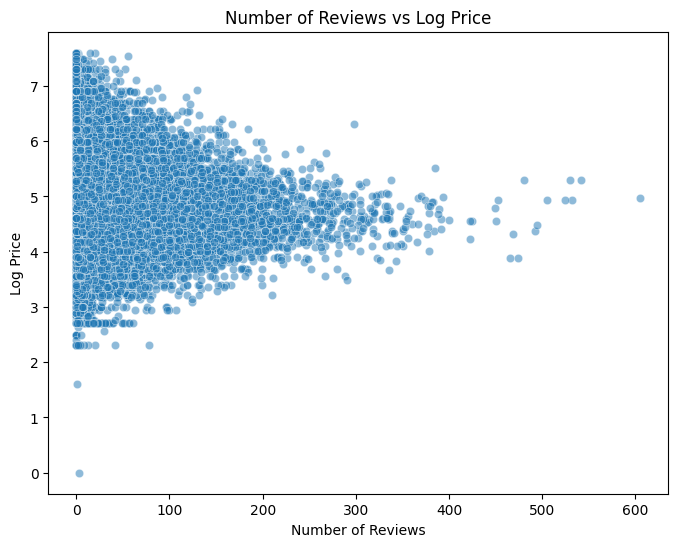

In [35]:
# Scatter plot of number of reviews vs log_price
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='number_of_reviews', y='log_price', alpha=0.5)
plt.title('Number of Reviews vs Log Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Log Price')
plt.show()

<Figure size 2000x2500 with 0 Axes>

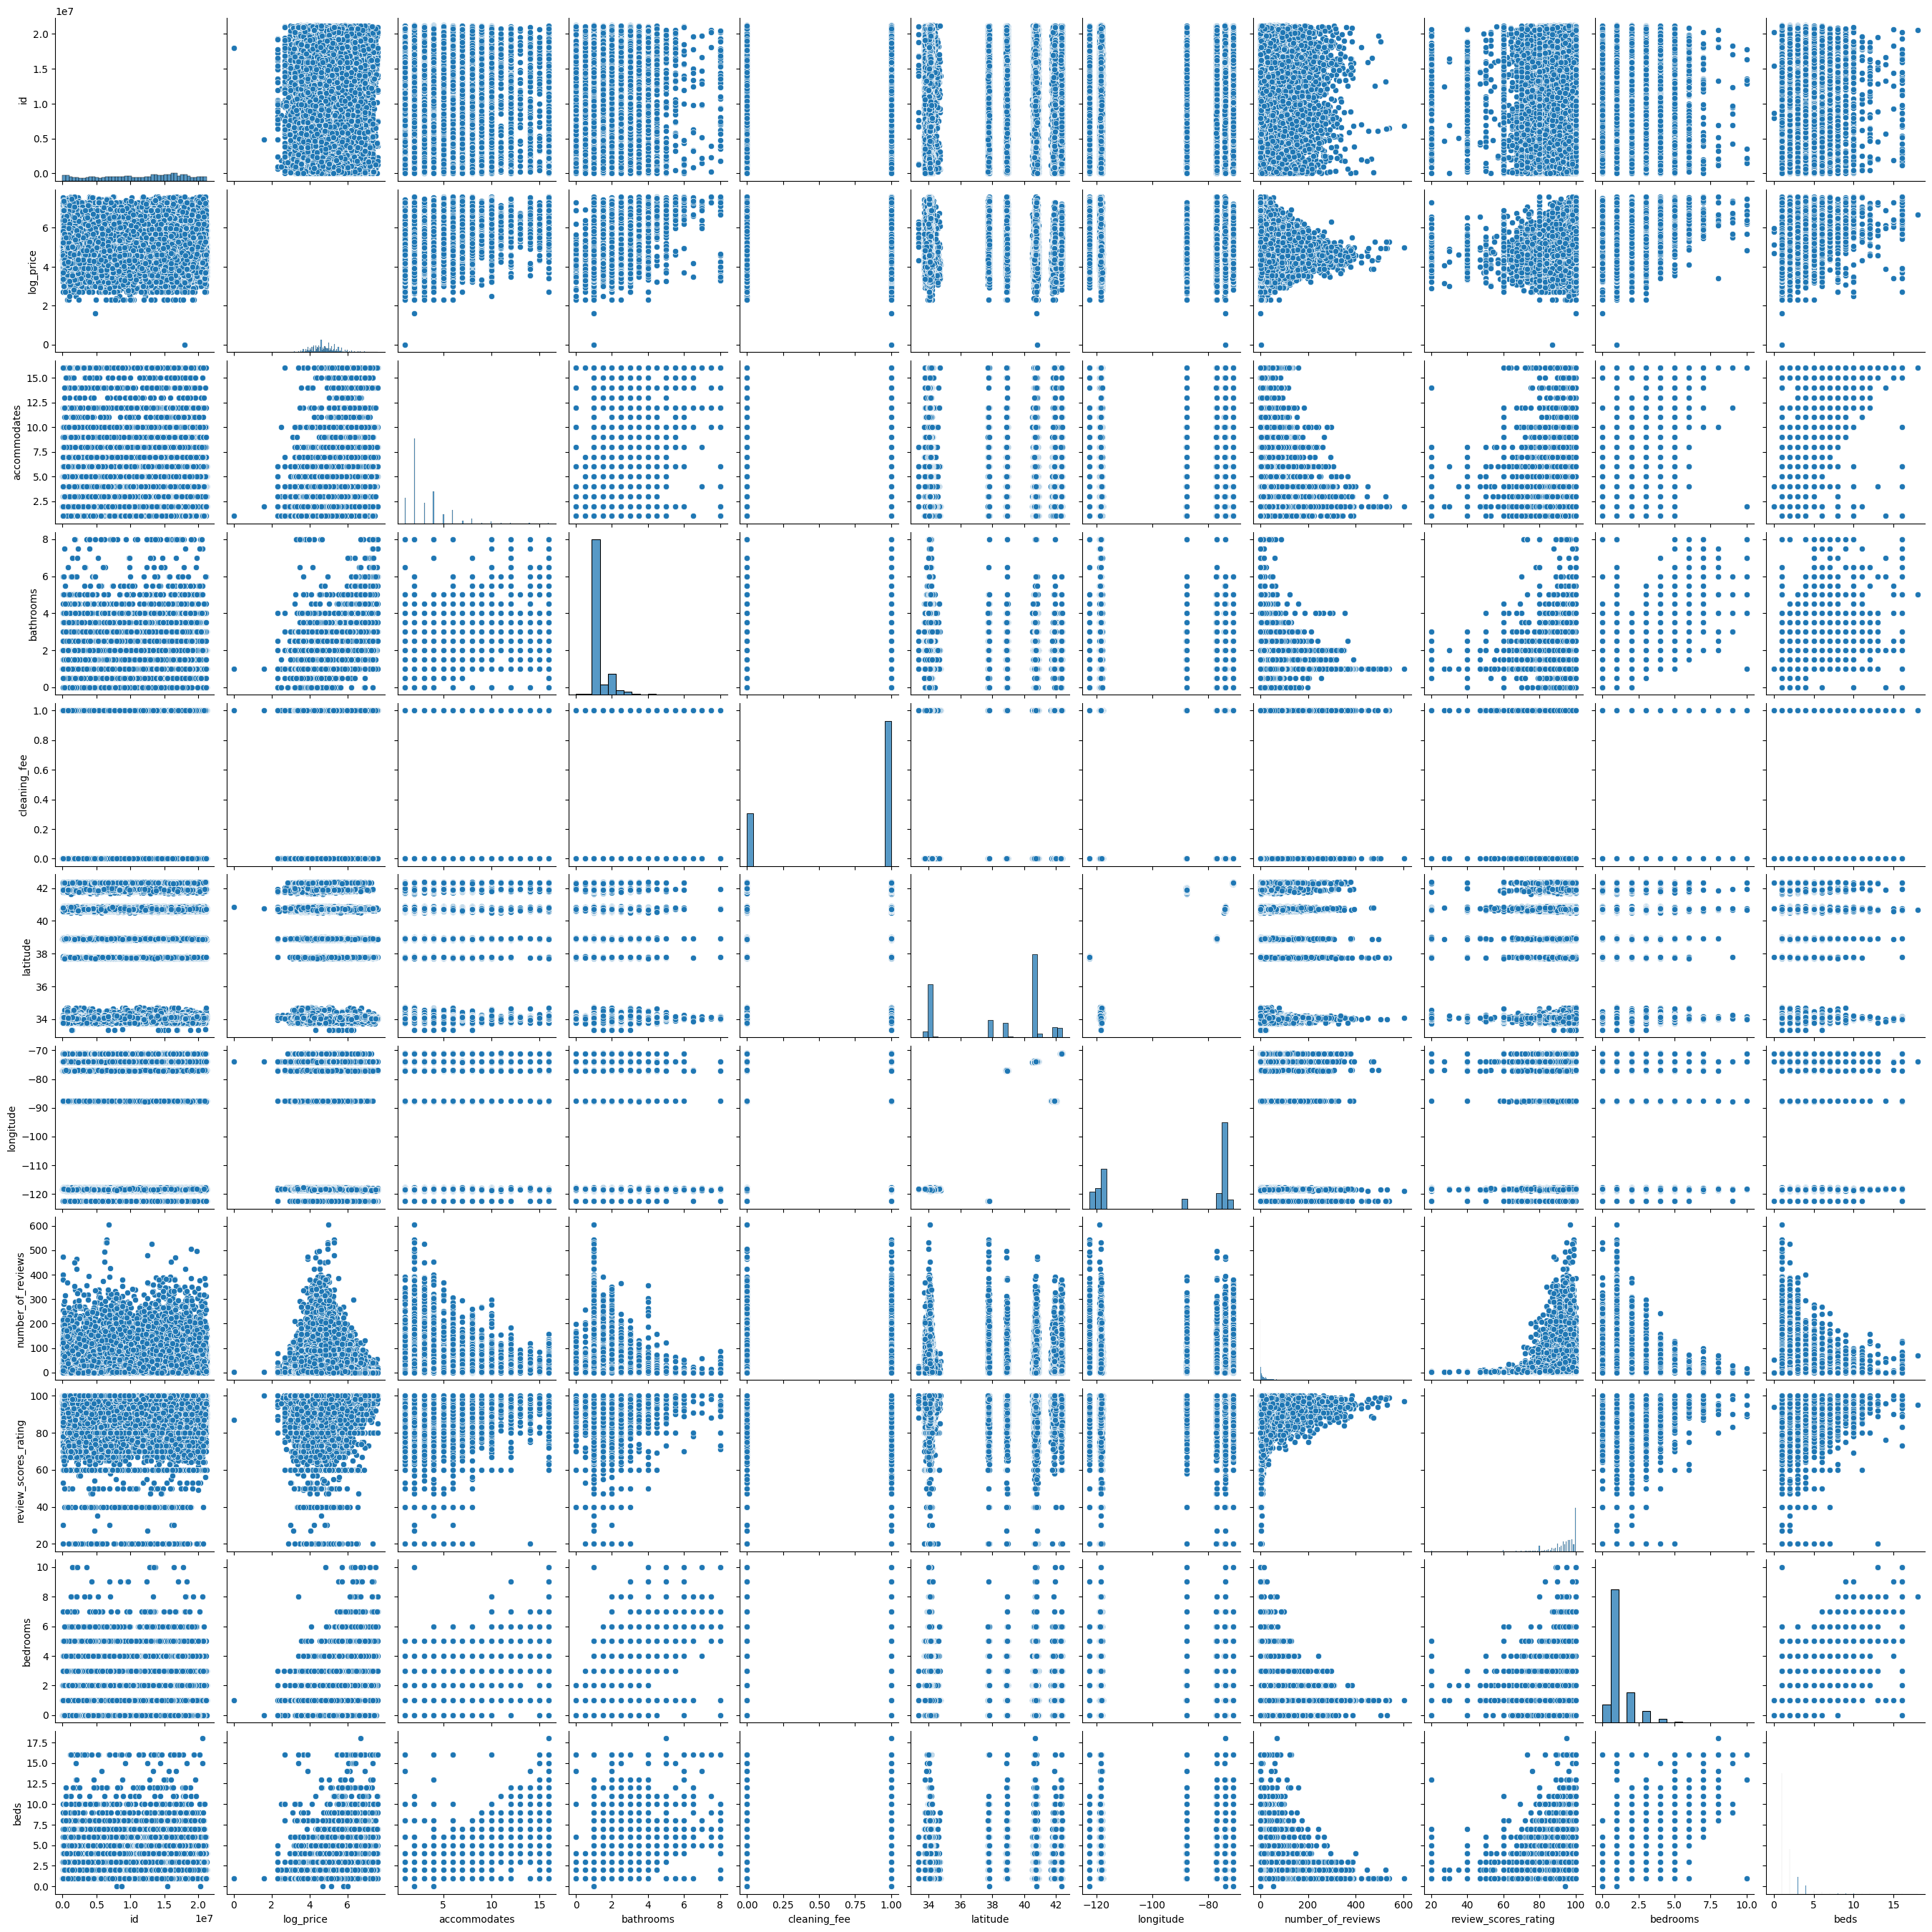

In [36]:
plt.figure(figsize=(20, 25))
sns.pairplot(data)

Listings with higher numbers of reviews tend to have mid-range prices, while luxury listings generally have fewer reviews.

#### G. Scatter Plot for geofraphic distribution

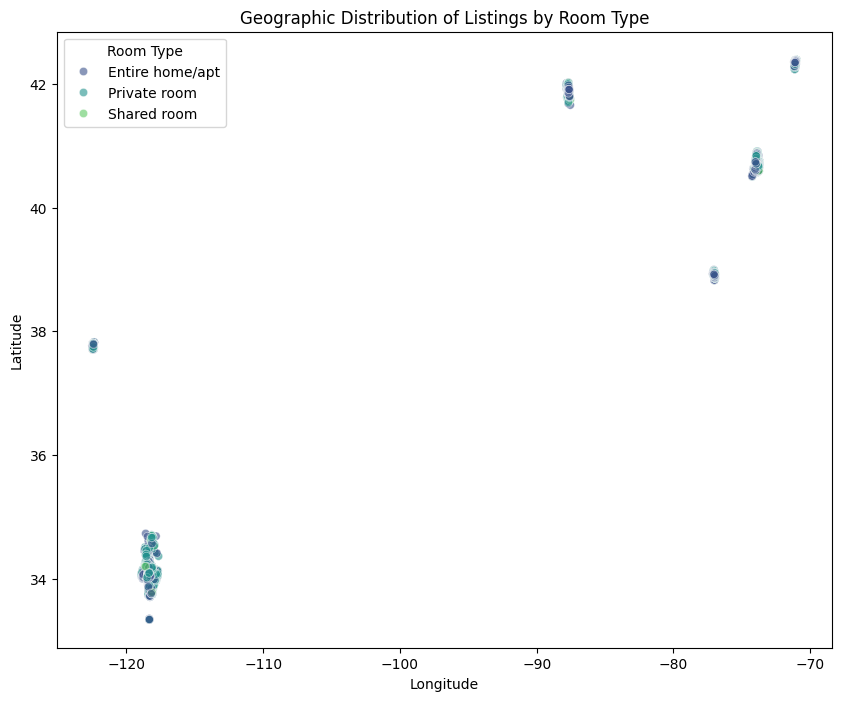

In [39]:
# Scatter plot for geographic distribution
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='longitude', y='latitude', hue='room_type', alpha=0.6, palette='viridis')
plt.title('Geographic Distribution of Listings by Room Type')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Room Type')
plt.show()

Listings cluster near major cities with distinct patterns for room types.

## **Phase 3: Data Cleaning**

#### Step1: Check null values

In [43]:
print(data.isnull().sum())

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     968
bedrooms                     91
beds                        131
dtype: int64


#### Step2: Handle missing values

In [45]:
# Handle missing values for numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Handle missing values for non-numeric columns
non_numeric_cols = data.select_dtypes(exclude=['number']).columns
data[non_numeric_cols] = data[non_numeric_cols].fillna(data[non_numeric_cols].mode().iloc[0])

# Remove rows where target price is missing
data = data.dropna(subset=['log_price'])

#checking the result
print(data.isnull().sum())

id                        0
log_price                 0
property_type             0
room_type                 0
amenities                 0
accommodates              0
bathrooms                 0
bed_type                  0
cancellation_policy       0
cleaning_fee              0
city                      0
description               0
first_review              0
host_has_profile_pic      0
host_identity_verified    0
host_response_rate        0
host_since                0
instant_bookable          0
last_review               0
latitude                  0
longitude                 0
name                      0
neighbourhood             0
number_of_reviews         0
review_scores_rating      0
thumbnail_url             0
zipcode                   0
bedrooms                  0
beds                      0
dtype: int64


#### Step3: Check missing values

In [47]:
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


#### Step4: Verify the missing values

In [49]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


## **Phase 4: Data Preprocessing**

### Step1: Box Plot Graph

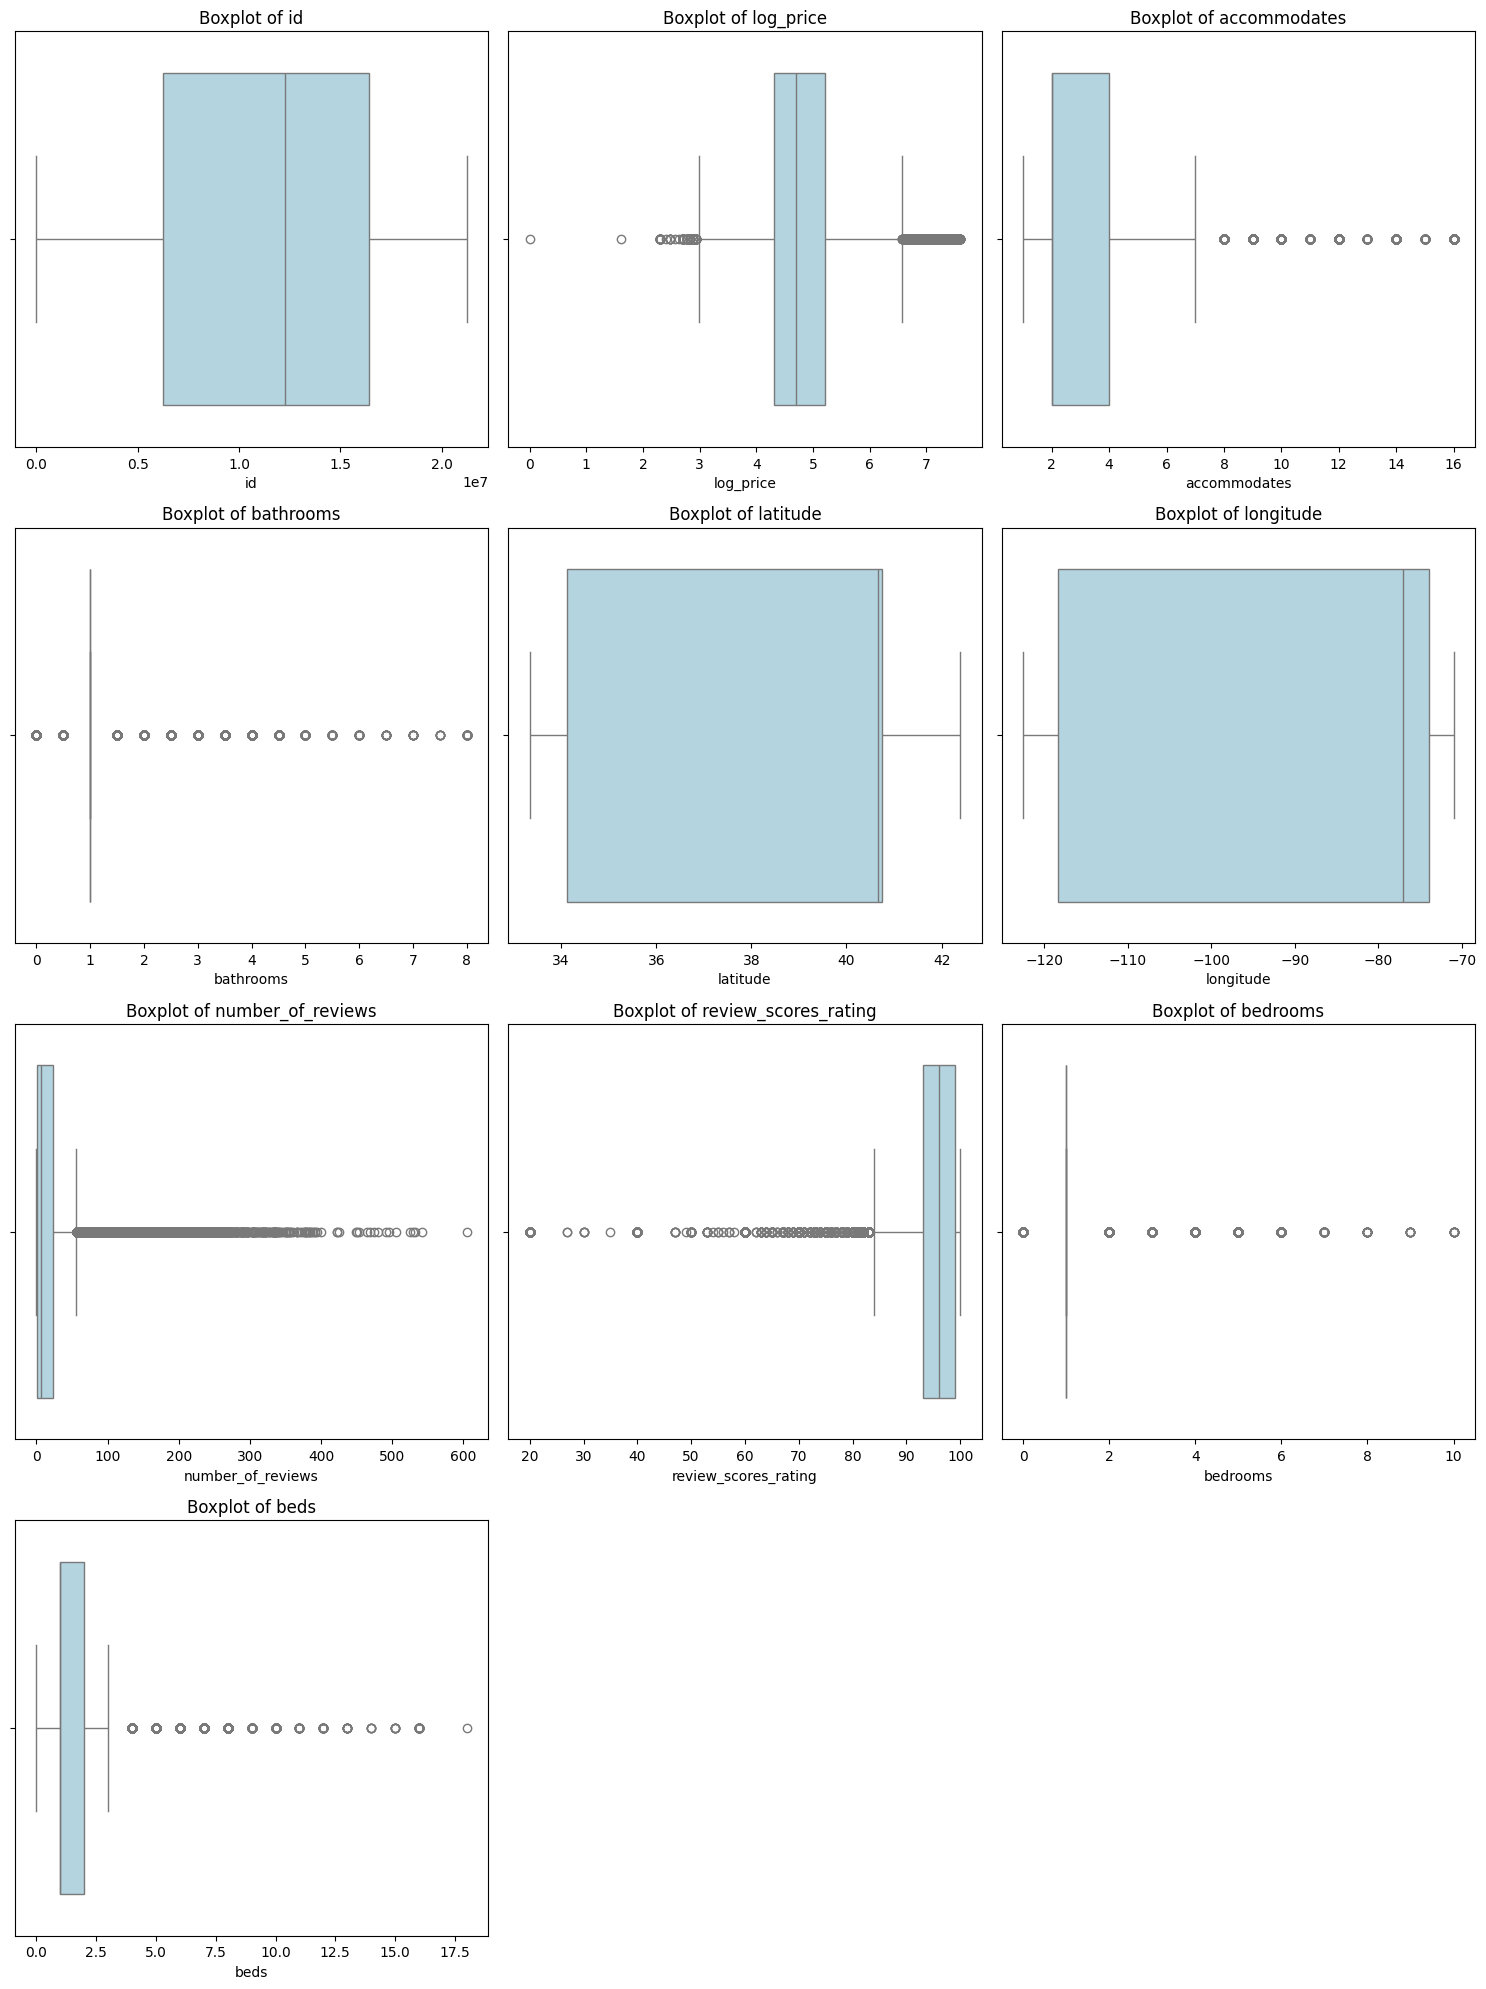

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# List of numeric columns in the dataset
numeric_columns = data.select_dtypes(include=['number']).columns

# Calculate the number of rows and columns needed for subplots
num_columns = 3  # Set the number of columns for subplots
num_rows = math.ceil(len(numeric_columns) / num_columns)  # Calculate the number of rows

# Set up the plot size
plt.figure(figsize=(15, num_rows * 5))

# Loop through each numeric column and create a boxplot
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(num_rows, num_columns, i)  # Adjust rows and columns based on the number of numeric columns
    sns.boxplot(x=data[column], color='lightblue')
    plt.title(f'Boxplot of {column}', fontsize=12)
    plt.xlabel(column, fontsize=10)

# Display the plots
plt.tight_layout()
plt.show()


### Boxplots Outlier Analysis 

Boxplots were used to identify potential outliers in the numerical variables of the Airbnb dataset. The analysis shows that several numerical features contain observations beyond the upper and lower whiskers, indicating the presence of potential outliers. In particular, Airbnb-related variables such as price, number of reviews, accommodates, bedrooms, bathrooms, or beds may contain extreme observations. These values should not be removed automatically because they may represent genuine Airbnb listings. The outliers will therefore be investigated further before deciding whether to retain, transform, cap, or remove them.

**Boxplot observation**	                           **Meaning**

- Points inside whiskers-	                     **Normal/typical observations**

- Points above upper whisker-	                 **Potential high-value outliers**

- Points below lower whisker-	                 **Potential low-value outliers**

- Long upper whisker-	                         **Right-skewed distribution may exist**

- Many points above the box-	                **Strong possibility of extreme values**

- Very large price outliers-	                **May represent luxury/high-end listings**

### Boxplot Analysis

**Variable**	**What the boxplot shows**	**Interpretation**

- **id**	No major visible outliers	ID is an identifier, not a meaningful predictive feature. It should generally be excluded from the ML model.
    
- **log_price**	Some low-value outliers and many high-side observations	Price is right-skewed even after log transformation; there are listings with unusually high prices.

- **accommodates**	Several observations above the upper whisker	A small number of properties accommodate unusually large numbers of guests.

- **bathrooms**	Many observations above the upper whisker	Most listings have relatively few bathrooms, while some properties have substantially more.

- **latitude**	No significant individual outliers visible	Latitude appears relatively well distributed within the dataset's geographic range.

- **longitude**	No major individual outliers visible	Longitude also appears to remain within the expected geographic range.

- **number_of_reviews**	Very large number of upper outliers	Reviews are strongly right-skewed. A small number of listings have hundreds of reviews compared with most listings.

- **review_scores_rating**	Several low-side outliers	Most ratings are high, but some listings have considerably lower ratings.

- **bedrooms**	Several upper outliers	Most listings have relatively few bedrooms, while a small number have many bedrooms.

- **beds**	Several upper outliers	Most properties have relatively few beds, with some larger properties having considerably more.

### Step2: Outlier Handling

In [59]:
Q1 = data['log_price'].quantile(0.25)
Q3 = data['log_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['log_price'] >= lower_bound) & 
            (data['log_price'] <= upper_bound)
]

In [60]:
print(data.shape)

(72579, 29)


In [61]:
print(data[['accommodates', 'bathrooms', 'bedrooms', 'beds']].nunique())

accommodates    16
bathrooms       16
bedrooms        11
beds            17
dtype: int64


### Step3: Preprocessing ensured data consistency and improved the model's robustness against noise.

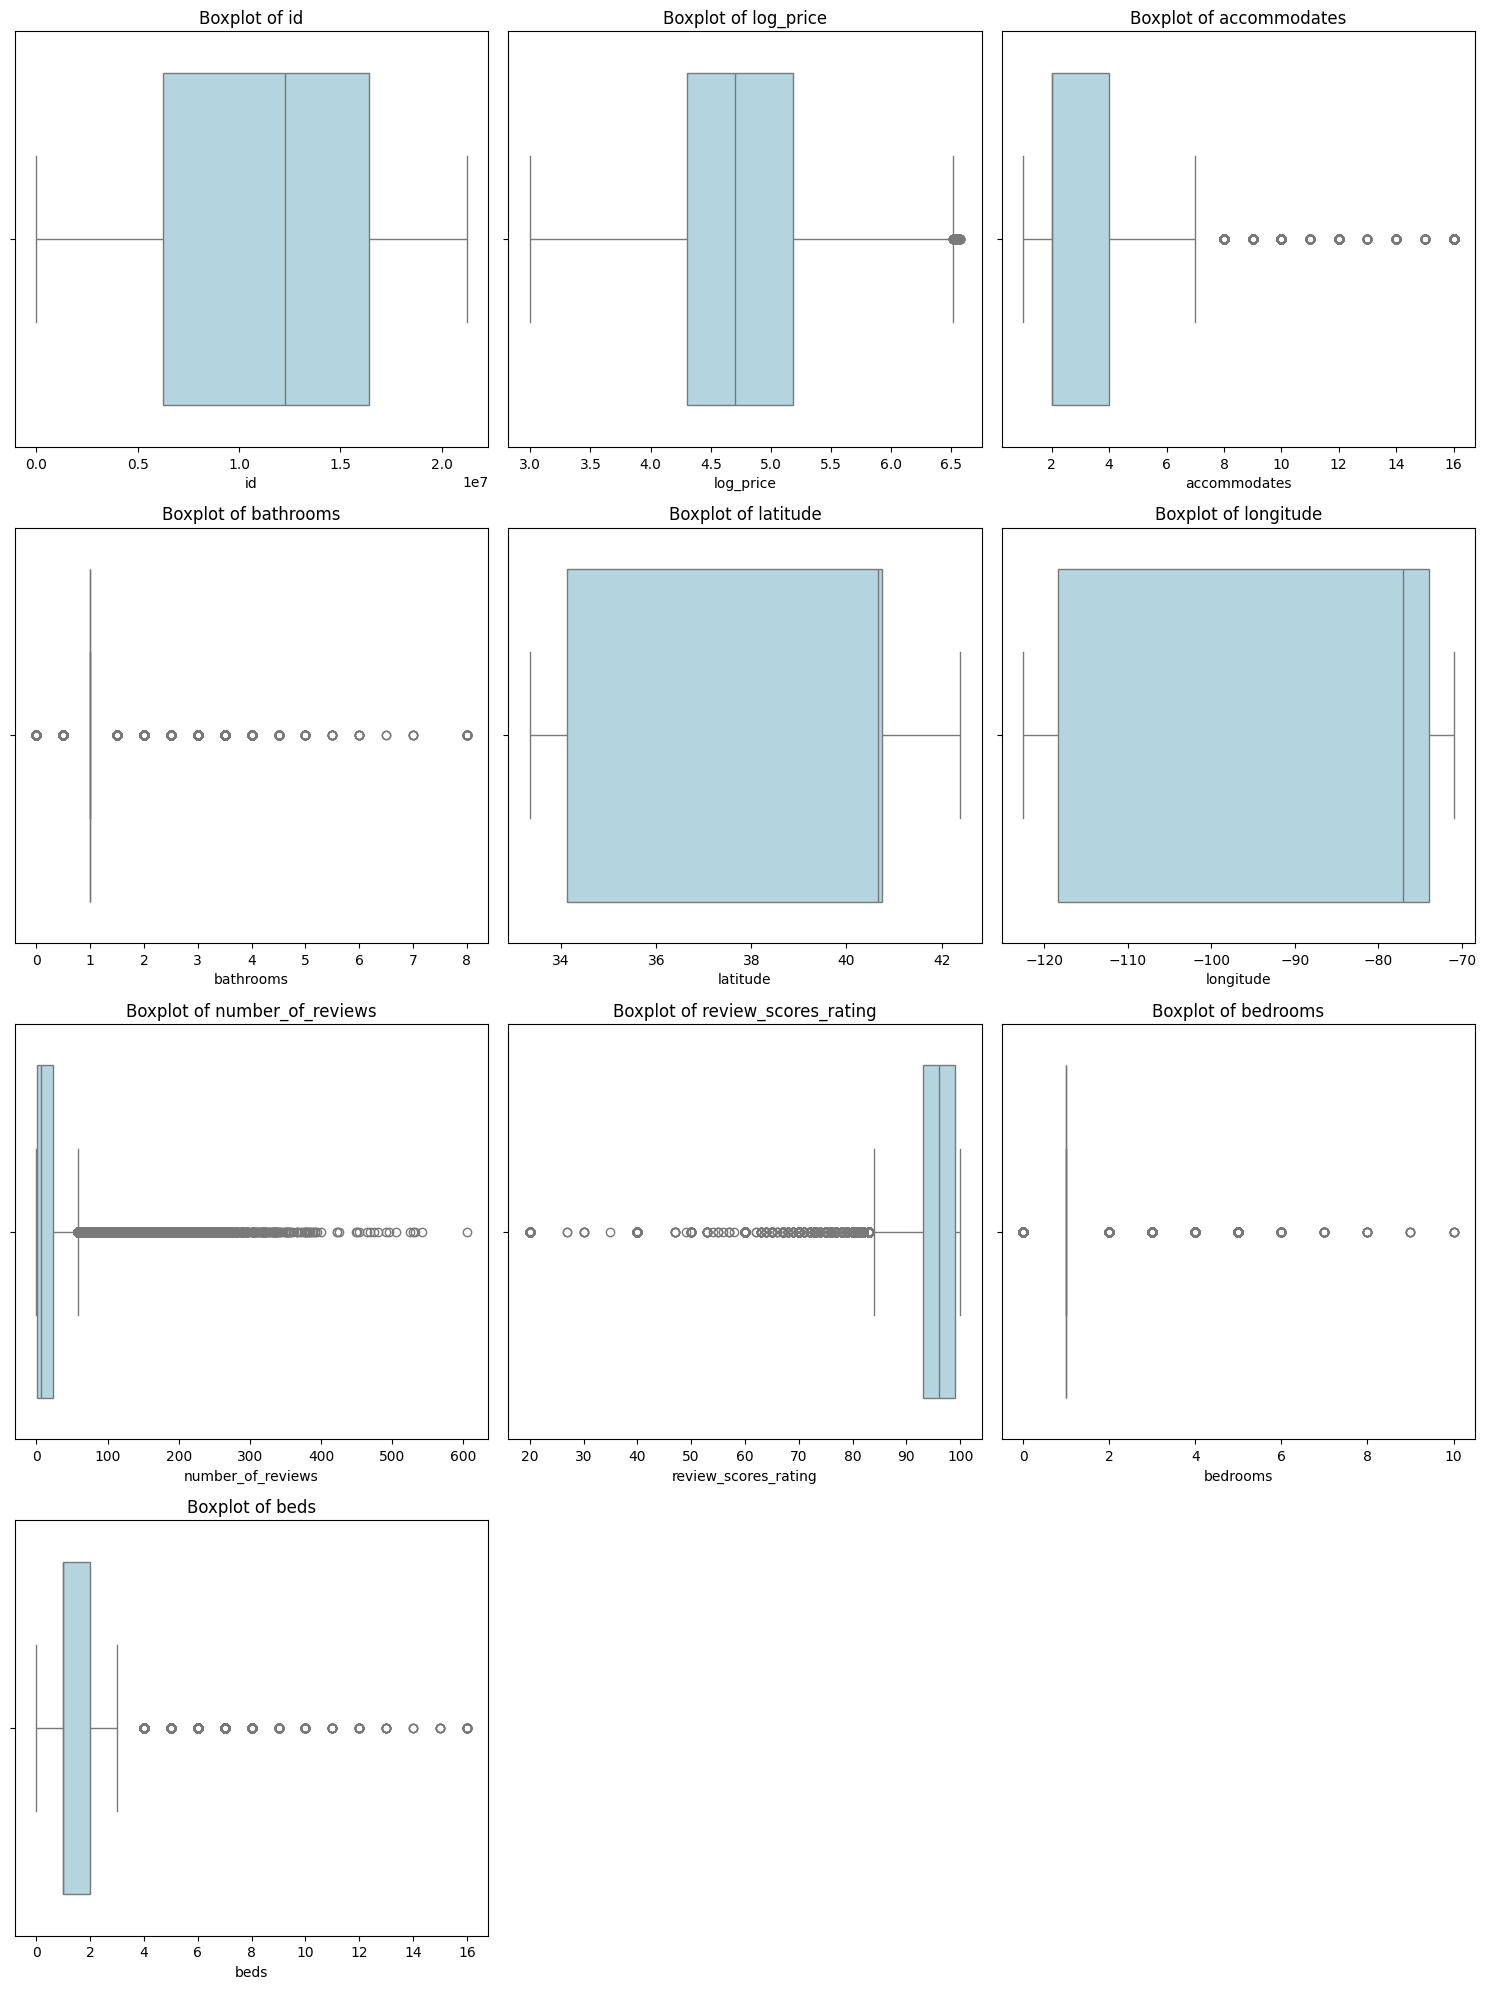

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# List of numeric columns in the dataset
numeric_columns = data.select_dtypes(include=['number']).columns

# Calculate the number of rows and columns needed for subplots
num_columns = 3  # Set the number of columns for subplots
num_rows = math.ceil(len(numeric_columns) / num_columns)  # Calculate the number of rows

# Set up the plot size
plt.figure(figsize=(15, num_rows * 5))

# Loop through each numeric column and create a boxplot
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(num_rows, num_columns, i)  # Adjust rows and columns based on the number of numeric columns
    sns.boxplot(x=data[column], color='lightblue')
    plt.title(f'Boxplot of {column}', fontsize=12)
    plt.xlabel(column, fontsize=10)

# Display the plots
plt.tight_layout()
plt.show()


Listings that accommodate more guests generally have higher log prices.
Outliers exist for luxury accommodations with fewer guest capacities.

Higher guest capacity correlates with higher prices.

## **Phase 5: Feature Engineering**

### Step1: Handle the null values before feature engineering

In [67]:
print(data.isnull().sum())

id                        0
log_price                 0
property_type             0
room_type                 0
amenities                 0
accommodates              0
bathrooms                 0
bed_type                  0
cancellation_policy       0
cleaning_fee              0
city                      0
description               0
first_review              0
host_has_profile_pic      0
host_identity_verified    0
host_response_rate        0
host_since                0
instant_bookable          0
last_review               0
latitude                  0
longitude                 0
name                      0
neighbourhood             0
number_of_reviews         0
review_scores_rating      0
thumbnail_url             0
zipcode                   0
bedrooms                  0
beds                      0
dtype: int64


### Step2: Amenities column

In [69]:
data['amenities_count'] = (
    data['amenities']
    .fillna('')
    .apply(lambda x: len(str(x).split(',')))
)

In [70]:
data[['amenities', 'amenities_count']].head()

,amenities,amenities_count
0,"{""Wireless Internet"",""Air conditioning"",Kitche...",9
1,"{""Wireless Internet"",""Air conditioning"",Kitche...",15
2,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",19
4,"{TV,Internet,""Wireless Internet"",""Air conditio...",12
5,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",10


### Step3: Summary of the columns

In [72]:
check_columns = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds'
]

print("Missing values:")
print(data[check_columns].isnull().sum())

print("\nUnique values:")
print(data[check_columns].nunique())

print("\nSummary:")
print(data[check_columns].describe())

print("\nDataset shape:")
print(data.shape)

Missing values:
accommodates    0
bathrooms       0
bedrooms        0
beds            0
dtype: int64

Unique values:
accommodates    16
bathrooms       16
bedrooms        11
beds            17
dtype: int64

Summary:
       accommodates     bathrooms      bedrooms          beds
count  72579.000000  72579.000000  72579.000000  72579.000000
mean       3.082200      1.208945      1.234875      1.669409
std        2.036157      0.518106      0.797733      1.173820
min        1.000000      0.000000      0.000000      0.000000
25%        2.000000      1.000000      1.000000      1.000000
50%        2.000000      1.000000      1.000000      1.000000
75%        4.000000      1.000000      1.000000      2.000000
max       16.000000      8.000000     10.000000     16.000000

Dataset shape:
(72579, 30)


### Step4: Apply Correlation Heatmap

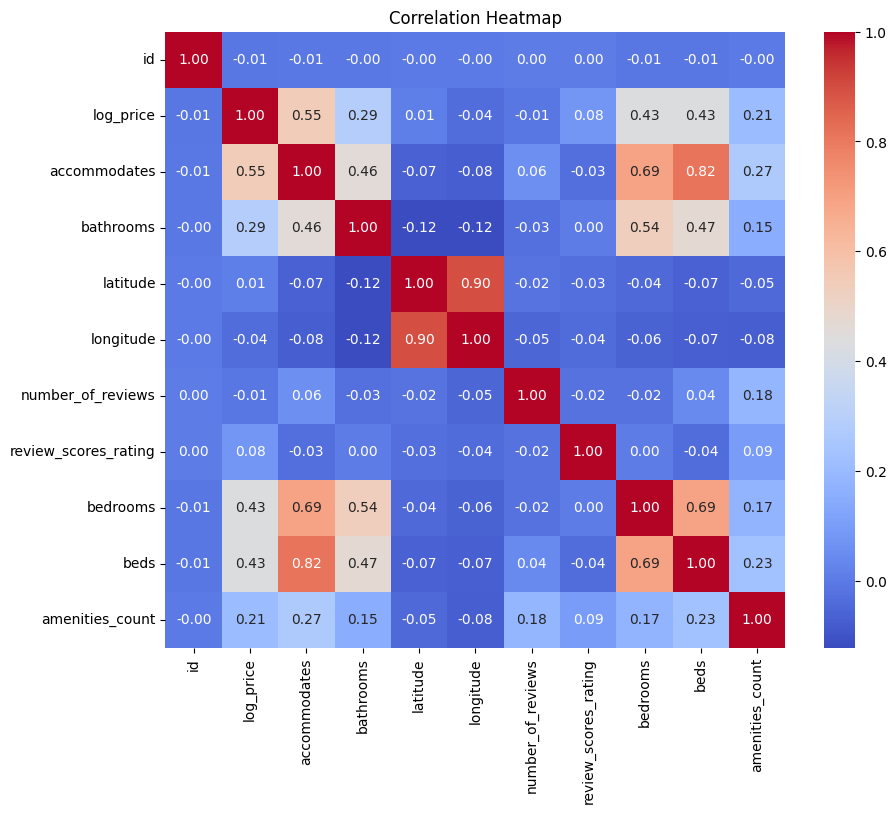

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute the correlation matrix for numeric features
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Correlation Heatmap')
plt.show()


Proper transformation of numerical and categorical data was crucial for model interpretability and performance.

## **Phase 6: Data Modeling**

### **Step1: Select Features and Target**

#### A. Check if data is a pandas DataFrame

In [79]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Step 1: Check if data is a pandas DataFrame and if required columns exist
print(type(data))  # Should print <class 'pandas.core.frame.DataFrame'>
print(data.columns)  # This should print a list of all column names

<class 'pandas.core.frame.DataFrame'>
Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds',
       'amenities_count'],
      dtype='object')


#### B. Define features and target

In [81]:
# Step 2: Define features and target
X = data[['property_type', 'room_type', 'neighbourhood', 'number_of_reviews', 'amenities_count']]  
y = data['log_price']

# Step 3: Preprocessing step for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['number_of_reviews', 'amenities_count']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['property_type', 'room_type', 'neighbourhood'])
    ]
)

#### C. Split data into training and testing sets

In [83]:
# Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Define models for comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

#### D. Check the results

In [85]:
# Step 6: Check the results
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (72579, 5)
y shape: (72579,)

Features:
['property_type', 'room_type', 'neighbourhood', 'number_of_reviews', 'amenities_count']

Target:
log_price


### **Step2: Model Selection**

In [87]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

### **Step3: Evaluate each model with cross-validation and test data**

In [89]:
import numpy as np

results = {}

for model_name, model in models.items():

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # Cross-validation ONLY on training data
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    # Convert negative MSE to RMSE
    cv_rmse = np.sqrt(-cv_scores.mean())

    # Train model
    pipeline.fit(X_train, y_train)

    # Predict test data
    y_pred = pipeline.predict(X_test)

    # Test metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[model_name] = {
        'CV RMSE': cv_rmse,
        'Test RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

    print(f"\n{model_name}")
    print(f"CV RMSE  : {cv_rmse:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"R²       : {r2:.4f}")


Linear Regression
CV RMSE  : 0.4425
Test RMSE: 0.4471
MAE      : 0.3423
R²       : 0.5333

Random Forest
CV RMSE  : 0.4653
Test RMSE: 0.4716
MAE      : 0.3597
R²       : 0.4808

Gradient Boosting
CV RMSE  : 0.4648
Test RMSE: 0.4712
MAE      : 0.3663
R²       : 0.4815


### Step4: Display the evaluation results

In [91]:
results_df = pd.DataFrame(results).T

print(results_df)

                    CV RMSE  Test RMSE       MAE        R²
Linear Regression  0.442548   0.447104  0.342253  0.533282
Random Forest      0.465287   0.471553  0.359731  0.480845
Gradient Boosting  0.464803   0.471237  0.366303  0.481540


## Results

**Linear Regression:**

Best performance with R² = 0.533, CV RMSE = 0.447, Test RMSE = 0.447

Weakness: Overfitting to the training data.

**Random Forest:**

Balanced performance (R² = 0.480, CV RMSE = 0.465, Test RMSE = 0.471).

Strength: Robustness against overfitting and non-linear relationships.

**Gradient Boosting:**

Slightly lower R² = 0.481 but CV RMSE = 0.464, Test RMSE = 0.471.

Strength: Handled nuanced interactions but was computationally expensive.

**Linear Regression provided the best R², but ensemble methods like Random Forest showed better overall robustness.**

## **Phase 7: Hyperparameter Tuning**

In [96]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd

# ==========================================
# STEP 1: HYPERPARAMETER GRIDS
# ==========================================

# Random Forest
rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

# Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.001, 0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}


# ==========================================
# STEP 2: STORE RESULTS
# ==========================================

optimized_results = {}


# ==========================================
# STEP 3: HYPERPARAMETER TUNING
# ==========================================

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # Select parameter grid
    if model_name == 'Random Forest':
        param_grid = rf_param_grid

    elif model_name == 'Gradient Boosting':
        param_grid = gb_param_grid

    else:
        param_grid = {}


    # Tune only RF and Gradient Boosting
    if param_grid:

        randomized_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=10,
            cv=3,
            scoring='neg_mean_squared_error',
            random_state=42,
            n_jobs=-1,
            verbose=2
        )

        # Fit on training data
        randomized_search.fit(X_train, y_train)

        # Best pipeline
        best_model = randomized_search.best_estimator_

        # Best parameters
        best_params = randomized_search.best_params_

        # Convert negative MSE to RMSE
        cv_rmse = np.sqrt(-randomized_search.best_score_)

        # Predict test data
        y_pred = best_model.predict(X_test)

        # Test metrics
        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        # Store results
        optimized_results[model_name] = {
            'Best Parameters': best_params,
            'CV RMSE': cv_rmse,
            'Test RMSE': rmse,
            'MAE': mae,
            'R²': r2
        }


# ==========================================
# STEP 4: DISPLAY RESULTS
# ==========================================

optimized_results_df = pd.DataFrame(
    optimized_results
).T

print(optimized_results_df)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
                                                     Best Parameters  \
Random Forest      {'model__n_estimators': 100, 'model__min_sampl...   
Gradient Boosting  {'model__subsample': 0.9, 'model__n_estimators...   

                    CV RMSE Test RMSE       MAE        R²  
Random Forest      0.459624  0.463386  0.357945  0.498671  
Gradient Boosting  0.431476  0.437396  0.335908  0.553331  


**Random Forest:**

Tuning parameters like n_estimators, max_depth, and min_samples_split resulted in improved RMSE (0.459) and R² (0.498).

**Gradient Boosting:**

Adjusting learning_rate, n_estimators, and max_depth provided RMSE = 0.431 and R² = 0.553.

Results indicated that fine-tuning improved Gradient Boosting's performance to surpass Random Forest.

## **Phase 8: Final Model Selection and Comparison**

### Step1: Comaprison DataFrame

In [100]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Random Forest (Tuned)',
        'Gradient Boosting',
        'Gradient Boosting (Tuned)'
    ],
    'RMSE': [
        results['Linear Regression']['Test RMSE'],
        results['Random Forest']['Test RMSE'],
        optimized_results['Random Forest']['Test RMSE'],
        results['Gradient Boosting']['Test RMSE'],
        optimized_results['Gradient Boosting']['Test RMSE']
    ],
    'MAE': [
        results['Linear Regression']['MAE'],
        results['Random Forest']['MAE'],
        optimized_results['Random Forest']['MAE'],
        results['Gradient Boosting']['MAE'],
        optimized_results['Gradient Boosting']['MAE']
    ],
    'R²': [
        results['Linear Regression']['R²'],
        results['Random Forest']['R²'],
        optimized_results['Random Forest']['R²'],
        results['Gradient Boosting']['R²'],
        optimized_results['Gradient Boosting']['R²']
    ]
})

print(comparison_df)

                       Model      RMSE       MAE        R²
0          Linear Regression  0.447104  0.342253  0.533282
1              Random Forest  0.471553  0.359731  0.480845
2      Random Forest (Tuned)  0.463386  0.357945  0.498671
3          Gradient Boosting  0.471237  0.366303  0.481540
4  Gradient Boosting (Tuned)  0.437396  0.335908  0.553331


**Hyperparameter optimization revealed the potential of ensemble methods to deliver strong predictions with careful tuning.**

### Step2: Comparison by Graph

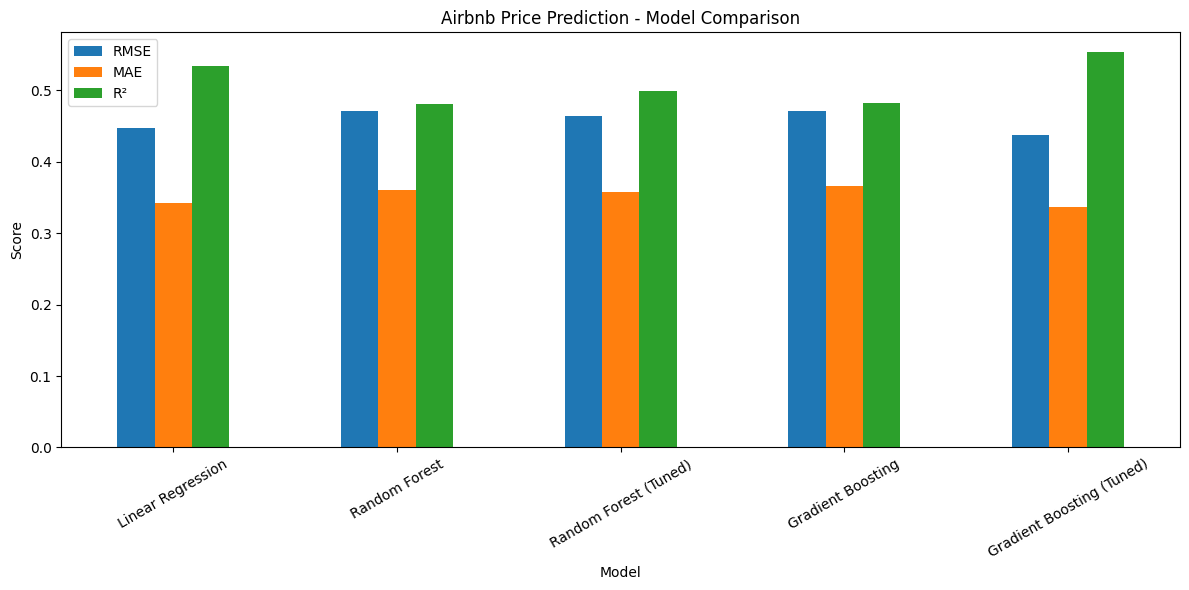

In [103]:
comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(12, 6),
    title='Airbnb Price Prediction - Model Comparison'
)

plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Linear Regression:** Best R² **(0.53)** but high RMSE **(0.47).**

**Random Forest**: Balanced performance **(R² = 0.48, RMSE = 0.47).**

**Gradient Boosting**:  R² **(0.48)** with similar RMSE **(0.47).**

### Hyperparameter tuned

**Random Forest (Tuned)**: Balanced performance (R² = 0.49, RMSE = 0.46).**

**Gradient Boosting (Tuned)**:  R² **(0.55)** with similar RMSE **(0.43).**

**Gradient Boosting** tuned is the best-performing model, but improvements are needed.

## **Phase 9: Final Model Selection**

### Step1: Boosting Pipeline

In [107]:
# Final Gradient Boosting Pipeline

final_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

### Step2: Gradient Boosting Model Creation

In [109]:
gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

gb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['number_of_reviews',
                                                                                'amenities_count']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['property_type',
                                                                                'room_type',
                                                                                'neighbourhood'])])),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.001, 0.01,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [50, 100, 200],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

### Step3: Gradient Boosting Model

In [111]:
final_model = gb_random_search.best_estimator_

print("Best Parameters:")
print(gb_random_search.best_params_)

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__learning_rate': 0.2}


## **Phase 10: Final Model Evaluation**

### Step1: Train the final model

In [114]:
y_pred_final = final_model.predict(X_test)

final_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_final)
)

final_mae = mean_absolute_error(
    y_test,
    y_pred_final
)

final_r2 = r2_score(
    y_test,
    y_pred_final
)

print("FINAL AIRBNB PRICE PREDICTION MODEL")
print("------------------------------------")
print(f"RMSE : {final_rmse:.4f}")
print(f"MAE  : {final_mae:.4f}")
print(f"R²   : {final_r2:.4f}")

FINAL AIRBNB PRICE PREDICTION MODEL
------------------------------------
RMSE : 0.4374
MAE  : 0.3359
R²   : 0.5533


#### Results


#### FINAL AIRBNB PRICE PREDICTION MODEL
------------------------------------
#### RMSE : 0.4374
#### MAE  : 0.3359
#### R²   : 0.5533

### Step2: Comparison the Price difference

In [118]:
# Convert log prices back to actual Airbnb prices

actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_pred_final)

# Create comparison DataFrame
actual_vs_predicted = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

# Calculate difference
actual_vs_predicted['Difference'] = (
    actual_vs_predicted['Actual Price']
    - actual_vs_predicted['Predicted Price']
)

# Display first 20 predictions
actual_vs_predicted.head(20)

,Actual Price,Predicted Price,Difference
0,49.0,72.732231,-23.732231
1,95.0,148.506615,-53.506615
2,59.0,43.183997,15.816003
3,349.0,148.373970,200.626030
4,124.0,124.938965,-0.938965
5,74.0,64.996643,9.003357
6,174.0,238.374570,-64.374570
7,128.0,159.628043,-31.628043
8,84.0,169.493322,-85.493322
9,89.0,72.659978,16.340022


#### Positive → model predicted lower than actual
#### Negative → model predicted higher than actual
#### Close to 0 → prediction is close to actual

### Step3: Actual vs Predicted Graph

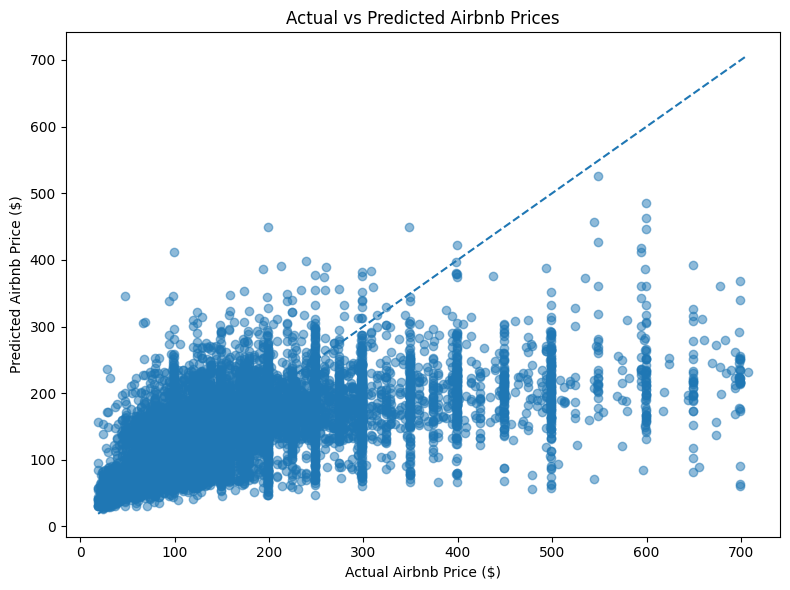

In [121]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_prices,
    predicted_prices,
    alpha=0.5
)

# Perfect prediction line
min_price = min(actual_prices.min(), predicted_prices.min())
max_price = max(actual_prices.max(), predicted_prices.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Airbnb Price ($)')
plt.ylabel('Predicted Airbnb Price ($)')
plt.title('Actual vs Predicted Airbnb Prices')

plt.tight_layout()
plt.show()

The Actual vs Predicted plot compares the model's predicted Airbnb prices with the actual prices from the test dataset. Points closer to the diagonal reference line indicate more accurate predictions

### Step4: Comparison Table

In [124]:
comparison_sample = actual_vs_predicted.sample(
    20,
    random_state=42
)

comparison_sample

,Actual Price,Predicted Price,Difference
11764,274.0,135.757074,138.242926
836,155.0,177.769701,-22.769701
1475,35.0,67.536469,-32.536469
1482,114.0,106.431685,7.568315
8008,28.0,52.574480,-24.574480
12603,94.0,85.062309,8.937691
5723,99.0,144.809597,-45.809597
8743,124.0,65.430622,58.569378
8439,54.0,71.577605,-17.577605
10296,39.0,55.328579,-16.328579


### Step5: Save the Model

In [126]:
import joblib

joblib.dump(
    final_model,
    'airbnb_price_prediction_pipeline.pkl'
)

print("Final model saved successfully.")

Final model saved successfully.


## **Phase 11: Create a prediction function**

### Step1: Apply function

In [129]:
def predict_airbnb_price(
    property_type,
    room_type,
    neighbourhood,
    number_of_reviews,
    amenities_count
):

    user_data = pd.DataFrame({
        'property_type': [property_type],
        'room_type': [room_type],
        'neighbourhood': [neighbourhood],
        'number_of_reviews': [number_of_reviews],
        'amenities_count': [amenities_count]
    })

    predicted_log_price = final_model.predict(user_data)[0]

    predicted_price = np.expm1(predicted_log_price)

    return predicted_price

### Step2: Test one Future Airbnb listing

In [131]:
price = predict_airbnb_price(
    property_type='Apartment',
    room_type='Entire home/apt',
    neighbourhood='Brooklyn Heights',
    number_of_reviews=50,
    amenities_count=15
)

print(f"Estimated Airbnb Price: ${price:.2f} per night")

Estimated Airbnb Price: $136.92 per night


# **Phase 12: User INPUT system**

In [133]:
print("============================================")
print("        AIRBNB PRICE PREDICTOR")
print("============================================")

property_type = input(
    "Enter Property Type: "
)

room_type = input(
    "Enter Room Type: "
)

neighbourhood = input(
    "Enter Neighbourhood: "
)

number_of_reviews = int(
    input("Enter Number of Reviews: ")
)

amenities_count = int(
    input("Enter Number of Amenities: ")
)

        AIRBNB PRICE PREDICTOR


Enter Property Type:  Apartment
Enter Room Type:  Entire home/apt
Enter Neighbourhood:  Brooklyn Heights
Enter Number of Reviews:  50
Enter Number of Amenities:  15


### For example: enter the input

Enter Property Type:  Apartment

Enter Room Type:  Entire home/apt

Enter Neighbourhood:  Brooklyn Heights

Enter Number of Reviews:  50

Enter Number of Amenities:  15

## Prediction Result

In [190]:
# Make the prediction based on user input
predicted_price = predict_airbnb_price(
    property_type=property_type,
    room_type=room_type,
    neighbourhood=neighbourhood,
    number_of_reviews=number_of_reviews,
    amenities_count=amenities_count
)

# Display the result

print("\n============================================")
print("          AIRBNB PRICE PREDICTION")
print("============================================")

print(f"Property Type      : {property_type}")
print(f"Room Type          : {room_type}")
print(f"Neighbourhood      : {neighbourhood}")
print(f"Number of Reviews  : {number_of_reviews}")
print(f"Amenities Count    : {amenities_count}")

print("--------------------------------------------")
print(f"Estimated Price    : ${predicted_price:.2f} per night")
print("============================================")


          AIRBNB PRICE PREDICTION
Property Type      : Apartment
Room Type          : Entire home/apt
Neighbourhood      : Brooklyn Heights
Number of Reviews  : 50
Amenities Count    : 15
--------------------------------------------
Estimated Price    : $136.92 per night


**Result**: the estimated price is $136.92 per night

## Key Insights

- **Room type** and **property type** are important factors affecting Airbnb prices.

- **Neighbourhood/location** plays a significant role in determining **listing prices**.

- Listings with more **amenities** can have **higher pricing potential**.
    
- **Number of reviews** provides useful information about listing activity, but more reviews do not necessarily mean **higher prices**.
    
- The dataset contained **missing values** and **outliers**, which were handled during preprocessing.

- **Gradient Boosting** performed best after hyperparameter tuning.

- **Final model performance**:
  R²: **0.5533**
  RMSE: **0.4374**
  MAE: **0.3359**

- The model can predict prices for new Airbnb listings, such as the demonstrated **$136.92/night prediction**.

## Recommendations

- Hosts should compare their price with similar properties in the same neighbourhood.

- Providing and highlighting useful amenities can support competitive pricing.

- Use the model as a pricing benchmark, not as an exact guaranteed price.

- Add more features such as accommodates, bedrooms, bathrooms, beds, review rating, and location coordinates to improve prediction accuracy.

- Improve amenities_count by identifying specific amenities such as Wi-Fi, parking, pool, kitchen, and air conditioning.
    
- Analyze premium/luxury listings separately, because the model may underpredict some high-priced properties.

## Conclusion

This project developed an **Interactive Prototype** with **analytical pipeline** in **Airbnb price prediction system** using **data preprocessing**, **exploratory data analysis**, **feature engineering**, **model comparison**, and **hyperparameter tuning**. The analysis identified important pricing-related characteristics such as room type, property type, neighbourhood, review activity, accommodation characteristics, and amenities. After comparing Linear Regression, Random Forest, and Gradient Boosting models, hyperparameter tuning substantially improved the Gradient Boosting model. **The final tuned Gradient Boosting model** achieved an **R²** of **0.5533**, **RMSE** of 0.4374**, and **MAE of 0.3359** on the test dataset. The model can estimate prices for new Airbnb listings, such as the demonstrated **$136.92 per-night estimate**. 

However, the model does not explain all price variation, particularly for some premium listings. Future improvements should include additional property characteristics, more detailed amenity features, geographic variables, and separate analysis of different price segments.